In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
path = Path("/content/Loan-Approval-Prediction.csv")

In [ ]:
data = pd.read_csv(path)

In [ ]:
data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [ ]:
data.shape

(614, 13)

In [ ]:
data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
609,False
610,False
611,False
612,False


In [ ]:
data.columns = data.columns.str.strip().str.lower().str.replace(" ", "_")

In [ ]:
data.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
data = data.rename(columns={'applicantincome': 'applicant_income', 'coapplicantincome': 'co_applicant_income', 'loanamount': 'loan_amount'})

In [ ]:
data.head(10)

,loan_id,gender,married,dependents,education,self_employed,applicant_income,co_applicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [ ]:
data.drop(['loan_id'], axis=1, inplace=True)

In [ ]:
data.head()

,gender,married,dependents,education,self_employed,applicant_income,co_applicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
missing_categorical_cols = ['gender', 'married', 'dependents', 'self_employed']
for col in missing_categorical_cols:
  data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_1739/2757858204.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
missing_numerical_cols = ['loan_amount_term', 'loan_amount', 'credit_history']
for col in missing_numerical_cols:
  data[col].fillna(data[col].median(), inplace=True)

/tmp/ipykernel_1739/2363296593.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


In [ ]:
data.isnull().sum()

,0
gender,0
married,0
dependents,0
education,0
self_employed,0
applicant_income,0
co_applicant_income,0
loan_amount,0
loan_amount_term,0
credit_history,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               614 non-null    int64  
 1   married              614 non-null    int64  
 2   dependents           614 non-null    int64  
 3   education            614 non-null    int64  
 4   self_employed        614 non-null    int64  
 5   applicant_income     614 non-null    int64  
 6   co_applicant_income  614 non-null    float64
 7   loan_amount          614 non-null    float64
 8   loan_amount_term     614 non-null    float64
 9   credit_history       614 non-null    float64
 10  property_area        614 non-null    int64  
 11  loan_status          614 non-null    int64  
 12  total_income         614 non-null    float64
 13  income_loan_ratio    614 non-null    float64
 14  total_income_log     614 non-null    float64
 15  loan_amount_log      614 non-null    flo

In [ ]:
data.to_csv('cleaned_dataset.csv', index=False)

In [ ]:
from google.colab import files
files.download('cleaned_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

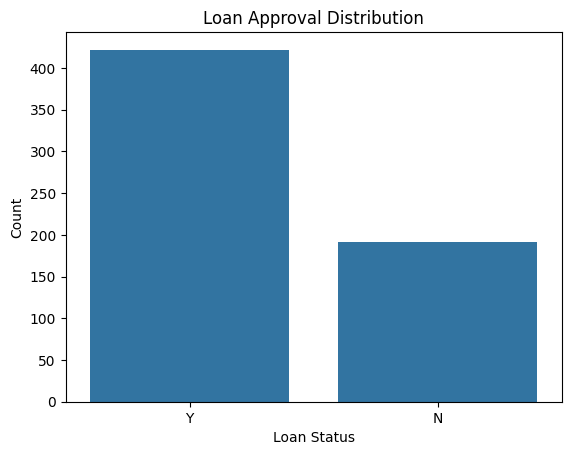

In [ ]:
import seaborn as sns
sns.countplot(x='loan_status', data=data)
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Loan Approval Distribution")
plt.show()

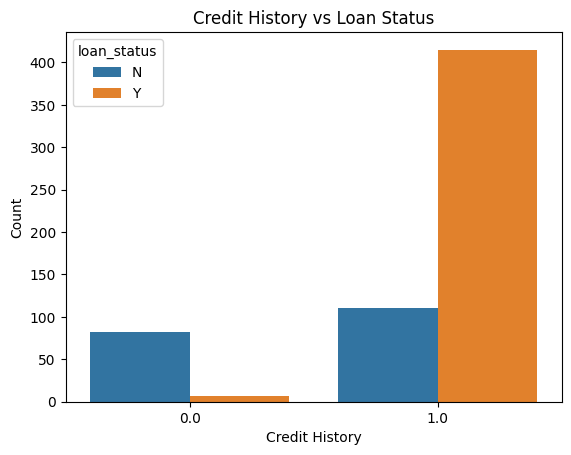

In [ ]:
sns.countplot(x='credit_history',hue='loan_status',data=data)
plt.xlabel("Credit History")
plt.ylabel("Count")
plt.title("Credit History vs Loan Status")
plt.show()

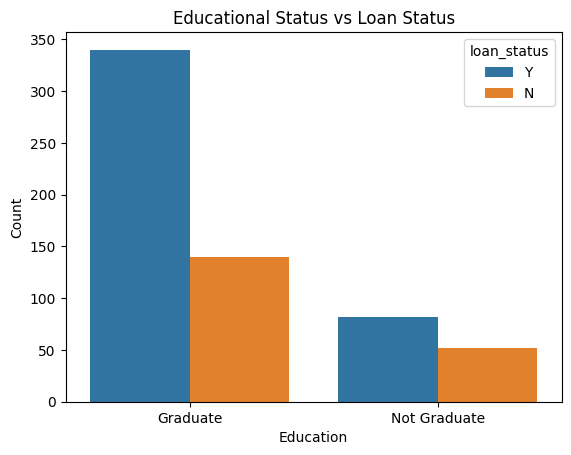

In [ ]:
sns.countplot(
    x='education',
    hue='loan_status',
    data=data
)
plt.xlabel("Education")
plt.ylabel("Count")
plt.title("Educational Status vs Loan Status")
plt.show()

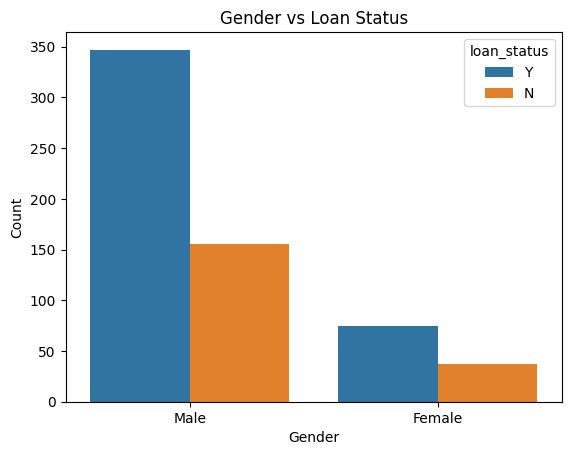

In [ ]:
sns.countplot(
    x='gender',
    hue='loan_status',
    data=data
)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender vs Loan Status")
plt.show()

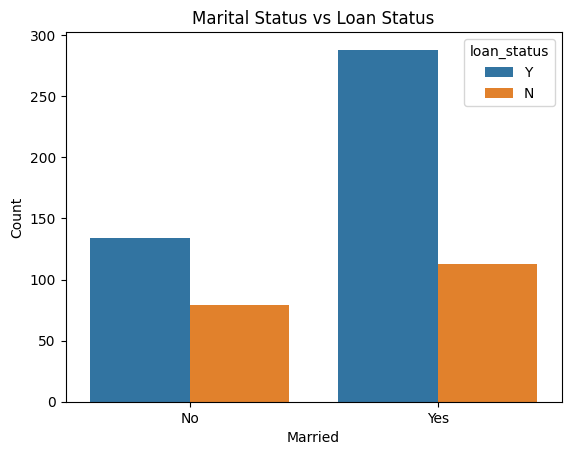

In [ ]:
sns.countplot(
    x='married',
    hue='loan_status',
    data=data
)
plt.xlabel("Married")
plt.ylabel("Count")
plt.title("Marital Status vs Loan Status")
plt.show()

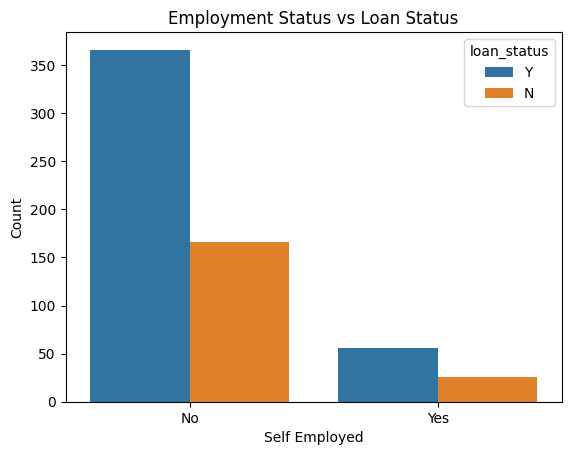

In [ ]:
sns.countplot(
    x='self_employed',
    hue='loan_status',
    data=data
)
plt.xlabel("Self Employed")
plt.ylabel("Count")
plt.title("Employment Status vs Loan Status")
plt.show()

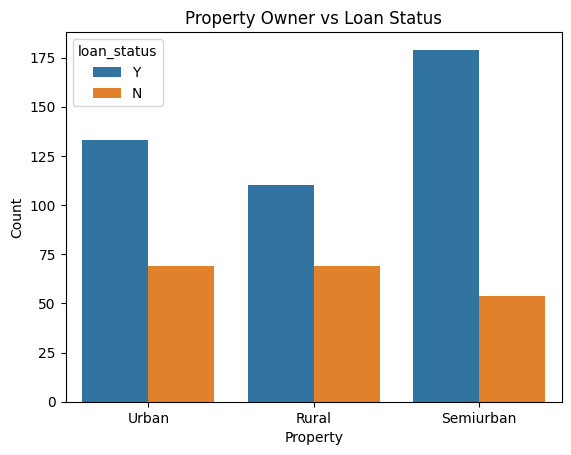

In [ ]:
sns.countplot(
    x='property_area',
    hue='loan_status',
    data=data
)
plt.xlabel("Property")
plt.ylabel("Count")
plt.title("Property Owner vs Loan Status")
plt.show()

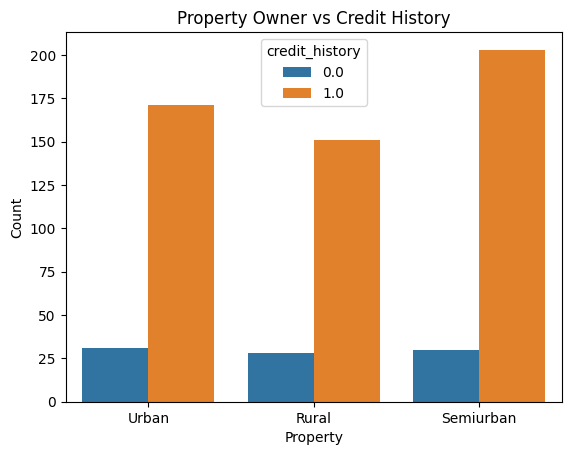

In [ ]:
sns.countplot(
    x='property_area',
    hue='credit_history',
    data=data
)
plt.xlabel("Property")
plt.ylabel("Count")
plt.title("Property Owner vs Credit History")
plt.show()

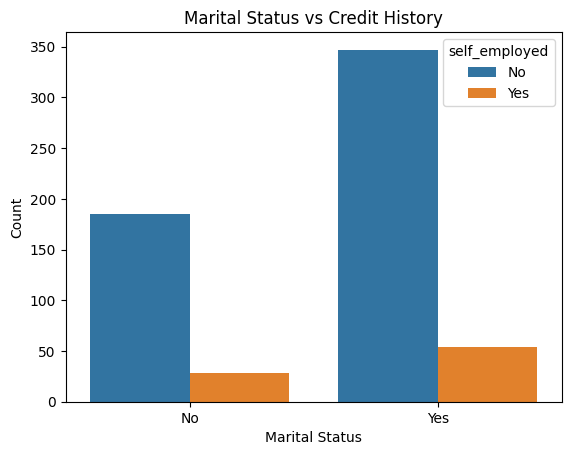

In [ ]:
sns.countplot(
    x='married',
    hue='self_employed',
    data=data
)
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.title("Marital Status vs Credit History")
plt.show()

<Axes: xlabel='applicant_income', ylabel='Count'>

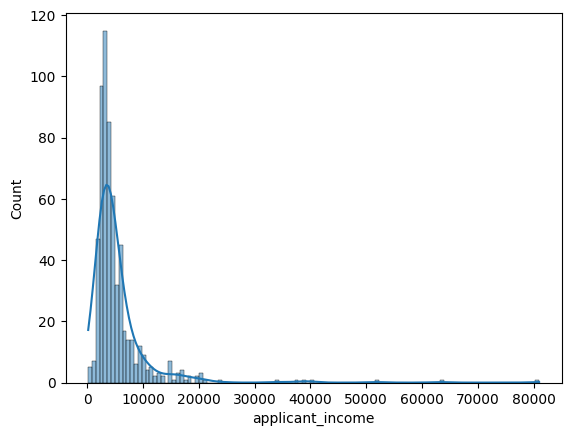

In [ ]:
sns.histplot(data['applicant_income'], kde=True)

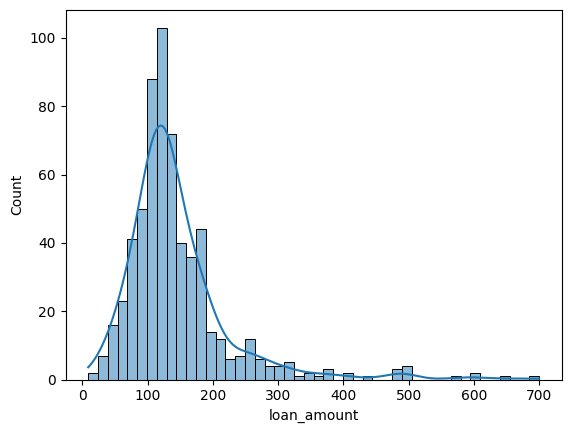

In [ ]:
sns.histplot(data['loan_amount'], kde=True)
plt.show()

In [ ]:
data['total_income'] = data['applicant_income'] + data['co_applicant_income']

<Axes: xlabel='total_income', ylabel='Count'>

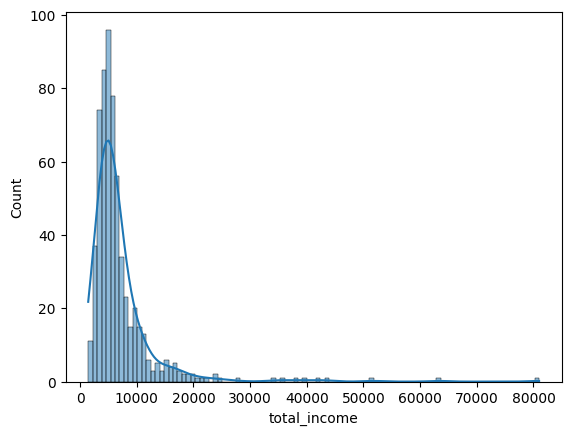

In [ ]:
sns.histplot(data['total_income'], kde=True)

In [ ]:
data['income_loan_ratio'] = (data['total_income'] / data['loan_amount'])

In [ ]:
data['total_income_log'] = np.log(data['total_income'])

data['loan_amount_log'] = np.log(data['loan_amount'])

<Axes: xlabel='total_income_log', ylabel='Count'>

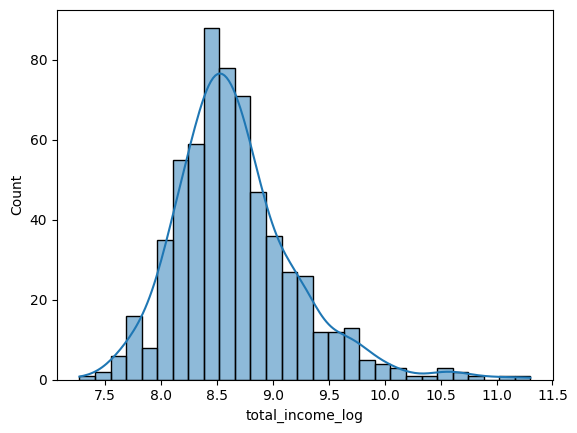

In [ ]:
sns.histplot(data['total_income_log'], kde=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical_columns = ['gender','married','education','self_employed',
                       'property_area','loan_status','dependents']

for col in categorical_columns:
    data[col] = le.fit_transform(data[col])

In [ ]:
X = data.drop(['loan_status'], axis=1)
y = data['loan_status']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

In [ ]:
print("Logistic Regression:",
      accuracy_score(y_test, lr_pred))

print("Decision Tree:",
      accuracy_score(y_test, dt_pred))

print("Random Forest:",
      accuracy_score(y_test, rf_pred))

Logistic Regression: 0.7804878048780488
Decision Tree: 0.6829268292682927
Random Forest: 0.7886178861788617


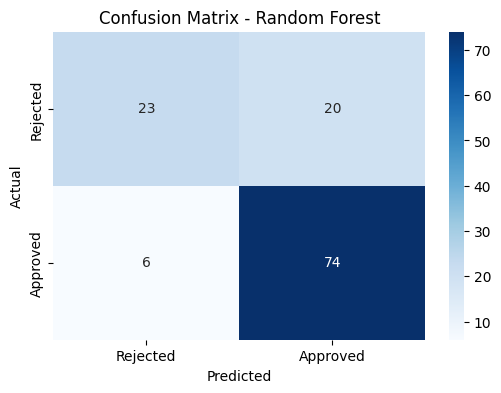

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [ ]:
report = classification_report(
    y_test,
    rf_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.793103,0.534884,0.638889,43.000000
1,0.787234,0.925000,0.850575,80.000000
accuracy,0.788618,0.788618,0.788618,0.788618
macro avg,0.790169,0.729942,0.744732,123.000000
weighted avg,0.789286,0.788618,0.776571,123.000000


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

importance

,Feature,Importance
9,credit_history,0.256841
12,income_loan_ratio,0.106089
13,total_income_log,0.099122
11,total_income,0.091645
5,applicant_income,0.088114
7,loan_amount,0.086480
14,loan_amount_log,0.076862
6,co_applicant_income,0.051671
8,loan_amount_term,0.034340
10,property_area,0.031803


In [ ]:
import pickle

pickle.dump(rf, open("loan_approval_model.pkl", "wb"))